# Refactorización de Notebook para Maximización de F1-Score (Fraude IEEE-CIS)
**Objetivo:** Implementación de estrategias avanzadas de preprocesamiento, Zero Data Leakage (Time-Based Split), Velocity Features, y Optimización Bayesiana Extrema con Threshold Moving.

## 1. Importación de Librerías

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc
import warnings
import datetime

import optuna
import category_encoders as ce

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Carga y Reducción de Memoria

In [12]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memoria reducida de {start_mem:.2f} MB a {end_mem:.2f} MB')
    return df

print("Cargando datasets...")
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
del train_transaction, train_identity
gc.collect()

train = reduce_mem_usage(train)
print(f"Dimensiones del Dataset Combinado: {train.shape}")

Cargando datasets...
Memoria reducida de 1955.37 MB a 645.97 MB
Dimensiones del Dataset Combinado: (590540, 434)


## 3. Ingeniería de Características y Velocity Features
Generación del `pseudo_user_id` y agregaciones temporales rodantes (24 horas).

In [13]:
df = train.copy()

# Ordenar cronológicamente todo el dataset (Pre-requisito para Leakage Prevention)
df.sort_values('TransactionDT', ascending=True, inplace=True)

# 1. Creación de pseudo_user_id
df['pseudo_user_id'] = (
    df['card1'].astype(str) + '_' +
    df['card2'].astype(str) + '_' +
    df['addr1'].astype(str) + '_' +
    df['P_emaildomain'].astype(str)
)

# 2. Velocity Features (requiere ordenar por usuario y tiempo)
df.sort_values(['pseudo_user_id', 'TransactionDT'], ascending=[True, True], inplace=True)

# time_since_last_txn
df['time_since_last_txn'] = df.groupby('pseudo_user_id')['TransactionDT'].diff().fillna(-1)

# Calcular txn_count_24h y amt_sum_24h usando un pandas rolling sobre una variable Date
start_date = datetime.datetime.strptime("2017-12-01", "%Y-%m-%d")
df['Date'] = df['TransactionDT'].apply(lambda dt: start_date + datetime.timedelta(seconds=dt))
df.set_index('Date', inplace=True)

# Agrupando por pseudo_user_id, aplicamos rolling de 24 horas continuas
rolling_groupby = df.groupby('pseudo_user_id')
df['txn_count_24h'] = rolling_groupby['TransactionID'].rolling('24h').count().reset_index(level=0, drop=True)
df['amt_sum_24h'] = rolling_groupby['TransactionAmt'].rolling('24h').sum().reset_index(level=0, drop=True)

df.reset_index(inplace=True)

# Transformaciones temporales y relacionales de la versión anterior
df['Transaction_Hour'] = df['Date'].dt.hour
df['Transaction_DayOfWeek'] = df['Date'].dt.dayofweek
df.drop(columns=['Date'], inplace=True)

# Transformación logarítmica
df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])

# Volver a ordenar por TransactionDT de forma estrictamente ascendente para el Time-Based Split futuro
df.sort_values('TransactionDT', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

print("Velocity Features Construidas Exitosamente.")

Velocity Features Construidas Exitosamente.


## 4. Tratamiento de Nulos y Columnas Vesta (Sin PCA)
Se preserva la escasez natural para que el árbol lo resuelva internamente.

In [14]:
null_percent = df.isnull().sum() / len(df)
cols_to_drop = null_percent[null_percent > 0.8].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"Se descartaron {len(cols_to_drop)} columnas con >80% de Nulos.")

v_cols = [c for c in df.columns if c.startswith('V')]
print(f"Mantenidas {len(v_cols)} columnas 'V' sin imputar ni reducir con PCA.")
gc.collect()

Se descartaron 74 columnas con >80% de Nulos.
Mantenidas 292 columnas 'V' sin imputar ni reducir con PCA.


22

## 5. Separación Temporal Estricta (Time-Based Split)
El 80% inicial para Train y 20% final para validación garantizan cero Leakage del futuro.

In [15]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
val_df = df.iloc[split_idx:].copy()

print(f"Train chronologically: {train_df['TransactionDT'].min()} to {train_df['TransactionDT'].max()}")
print(f"Val chronologically: {val_df['TransactionDT'].min()} to {val_df['TransactionDT'].max()}")

drop_cols = ['TransactionID', 'TransactionDT']
for c in drop_cols:
    if c in train_df.columns:
        train_df.drop(columns=[c], inplace=True)
        val_df.drop(columns=[c], inplace=True)

y_train = train_df.pop('isFraud')
X_train = train_df

y_val = val_df.pop('isFraud')
X_val = val_df

print(f"Train Shape: {X_train.shape}, Val Shape: {X_val.shape}")

Train chronologically: 86400 to 12192842
Val chronologically: 12192900 to 15811131
Train Shape: (472432, 364), Val Shape: (118108, 364)


## 6. Target Encoding Robusto
El `fit_transform` transcurre exclusivamente sobre X_train. Transform sobre X_val.

In [16]:
te_cols = ['card1', 'card2', 'addr1', 'P_emaildomain', 'pseudo_user_id']
te_cols = [c for c in te_cols if c in X_train.columns]

print(f"Aplicando Target Encoding en: {te_cols}")
target_enc = ce.TargetEncoder(cols=te_cols, smoothing=10.0)

# El fit SOLO MIRA datos del train para evitar contaminaciones del set validación
X_train[te_cols] = target_enc.fit_transform(X_train[te_cols].astype(str), y_train)

# Transform proyecta los pesos mapeados sobre Validación
X_val[te_cols] = target_enc.transform(X_val[te_cols].astype(str))

print("Target Encoding Aplicado Exitosamente (Cero Leakage).")

# Castear todos loose objects a categories para que el backend (LightGBM) lo use
object_cols = X_train.select_dtypes(include=['object']).columns
for col in object_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

Aplicando Target Encoding en: ['card1', 'card2', 'addr1', 'P_emaildomain', 'pseudo_user_id']
Target Encoding Aplicado Exitosamente (Cero Leakage).


## 7. Optimización Bayesiana Extrema (Objective: F1-Score + Threshold Moving)
Optuna maximiza nuestro F1 tras encontrar el umbral dinámico perfecto de corte.

In [17]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision', # Mejor que AUC para imbalance
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 150),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 10.0, 40.0),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'seed': 42,
        'verbose': -1
    }
    
    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)
    
    callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
    
    gbm = lgb.train(
        params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_train, lgb_val],
        callbacks=callbacks
    )
    
    # 1. Probabilidades Crudas
    y_pred_prob = gbm.predict(X_val)
    
    # 2. Precision-Recall Curve Threshold Moving
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_prob)
    fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
    
    # 3. Identificar y retornar F1-Score Máximo lograble en este trial particular
    max_f1 = np.max(fscores)
    
    return max_f1

print("Iniciando Estudio Optuna (Limitado preventivamente a 30 rondas)...")
study = optuna.create_study(direction='maximize', study_name="LGBM_F1_Optimization")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("============ RESULTADOS DE OPTIMIZACIÓN ============")
print("Mejor F1-Score encontrado en validación:", study.best_value)
print("Mejores Parámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-03-24 20:25:32,726] A new study created in memory with name: LGBM_F1_Optimization


Iniciando Estudio Optuna (Limitado preventivamente a 30 rondas)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-24 20:26:54,770] Trial 0 finished with value: 0.5380782917661793 and parameters: {'learning_rate': 0.043210148076990945, 'num_leaves': 107, 'max_depth': 14, 'min_data_in_leaf': 65, 'lambda_l1': 0.3348637739584409, 'lambda_l2': 0.6467466062714198, 'scale_pos_weight': 27.16920791081548, 'feature_fraction': 0.5982368515441012, 'bagging_fraction': 0.5036328673192114, 'bagging_freq': 10}. Best is trial 0 with value: 0.5380782917661793.
[I 2026-03-24 20:27:57,845] Trial 1 finished with value: 0.5052570934268995 and parameters: {'learning_rate': 0.011311930790929759, 'num_leaves': 47, 'max_depth': 7, 'min_data_in_leaf': 88, 'lambda_l1': 0.003128070224819387, 'lambda_l2': 0.003184343560908413, 'scale_pos_weight': 33.23595043195692, 'feature_fraction': 0.6950536702631863, 'bagging_fraction': 0.7173743852408004, 'bagging_freq': 10}. Best is trial 0 with value: 0.5380782917661793.
[I 2026-03-24 20:29:03,713] Trial 2 finished with value: 0.5305310990707574 and parameters: {'learning_rat

## 8. Entrenamiento Definitivo y Curvas
Aplicamos los hiperparámetros ganadores y proyectamos la métrica clasificador final.

Construyendo el Modelo Superior...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1301]	training's average_precision: 1	valid_1's average_precision: 0.555244
-> ROC-AUC Validation                 : 0.8822
-> Umbral Dinámico de Corte (T*)      : 0.5366
-> Mejor F1-Score de Retención (Test) : 0.5657


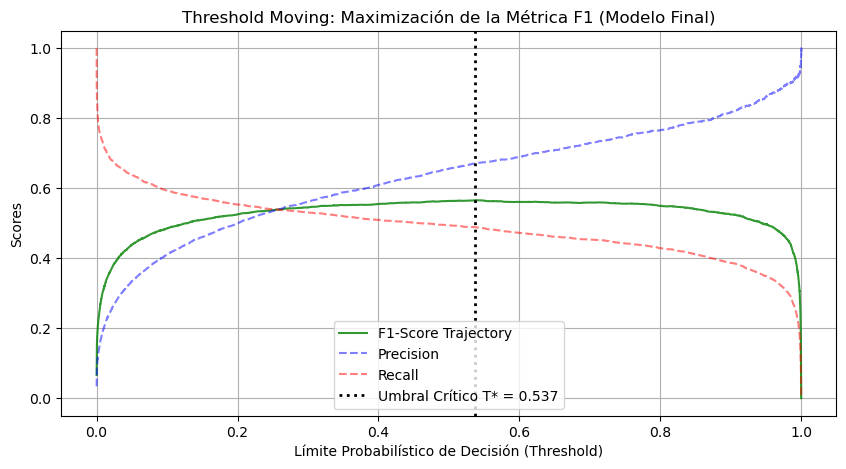

In [18]:
best_params = study.best_params
best_params.update({
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'seed': 42,
    'verbose': -1
})

lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

print("Construyendo el Modelo Superior...")
final_model = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_val],
    callbacks=callbacks
)

# Predicción Final
y_pred_prob_final = final_model.predict(X_val)
roc_auc = roc_auc_score(y_val, y_pred_prob_final)

# Evaluación Threshold T*
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_prob_final)
fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
optimal_idx = np.argmax(fscores)

optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_f1 = fscores[optimal_idx]

print(f"-> ROC-AUC Validation                 : {roc_auc:.4f}")
print(f"-> Umbral Dinámico de Corte (T*)      : {optimal_threshold:.4f}")
print(f"-> Mejor F1-Score de Retención (Test) : {optimal_f1:.4f}")

plt.figure(figsize=(10,5))
plt.plot(thresholds, fscores[:-1], "g-", alpha=0.8, label="F1-Score Trajectory")
plt.plot(thresholds, precisions[:-1], "b--", alpha=0.5, label="Precision")
plt.plot(thresholds, recalls[:-1], "r--", alpha=0.5, label="Recall")
plt.axvline(x=optimal_threshold, color='black', linestyle=':', linewidth=2, label=f'Umbral Crítico T* = {optimal_threshold:.3f}')
plt.xlabel("Límite Probabilístico de Decisión (Threshold)")
plt.ylabel("Scores")
plt.title("Threshold Moving: Maximización de la Métrica F1 (Modelo Final)")
plt.legend()
plt.grid()
plt.show()

## 9. Reporte Auditoría Clasificatoria
Representación con el Threshold Óptimo.

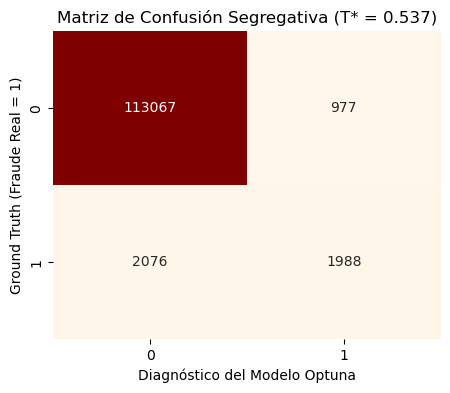

============= REPORTE FINAL DE AUDITORÍA (En base a T*) =============
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    114044
           1       0.67      0.49      0.57      4064

    accuracy                           0.97    118108
   macro avg       0.83      0.74      0.78    118108
weighted avg       0.97      0.97      0.97    118108



In [19]:
# Binarizamos agresivamente usando nuestra propia predicción calibrada (T*)
y_pred_optimal = (y_pred_prob_final >= optimal_threshold).astype(int)

cm = confusion_matrix(y_val, y_pred_optimal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', cbar=False)
plt.title(f'Matriz de Confusión Segregativa (T* = {optimal_threshold:.3f})')
plt.ylabel('Ground Truth (Fraude Real = 1)')
plt.xlabel('Diagnóstico del Modelo Optuna')
plt.show()

print("============= REPORTE FINAL DE AUDITORÍA (En base a T*) =============")
print(classification_report(y_val, y_pred_optimal))